In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('./input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
%pip install torchinfo
import PIL
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import re, os, sys, json, cv2, random
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchinfo import summary
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score, confusion_matrix, classification_report
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


In [1]:
!kaggle datasets download -d kmader/food41

Dataset URL: https://www.kaggle.com/datasets/kmader/food41
License(s): copyright-authors
food41.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import zipfile

with zipfile.ZipFile('./food41.zip', 'r') as zip_ref:
    zip_ref.extractall('./dataset')

waffles                : 100%|███████████████████████████████████████████| 200/200 [00:00<00:00, 930.80file/s]


101 kind of images were found in the dataset
101000 images were found in the dataset.
16158 for training, 4040 for validation
average image height=  473  average image width=  493  aspect ratio h/w=  0.9594320486815415


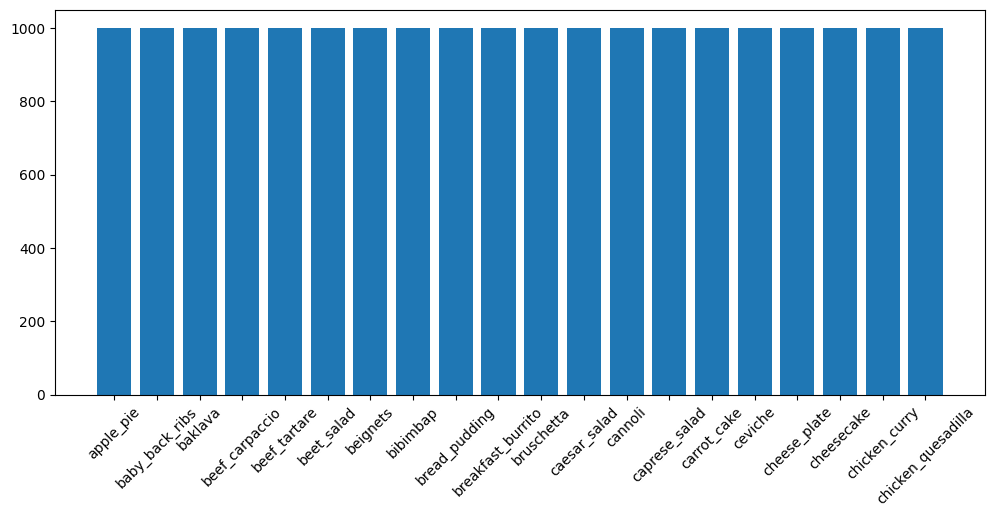

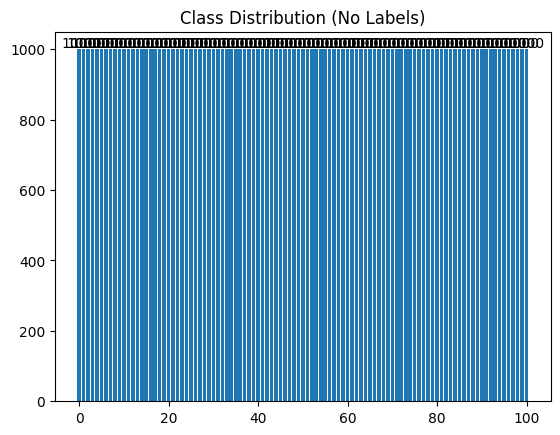

In [3]:
root = './dataset/images'
def read_split_data(root, plot_image=False):
    filepaths = []
    labels = []
    bad_images = []
 
    random.seed(0)
    assert os.path.exists(root), 'wdnmd'
 
    classes = [cla for cla in os.listdir(root) if os.path.isdir(os.path.join(root, cla))]
    classes.sort()
    class_indices = {k: v for v, k in enumerate(classes)}
 
    json_str = json.dumps({v: k for k, v in class_indices.items()}, indent=4)
 
    with open('classes_indices.json', 'w') as json_file:
        json_file.write(json_str)
 
    every_class_num = []
    supported = ['.jpg', '.png', '.jpeg', '.PNG', '.JPG', '.JPEG']
 
    for klass in classes:
        classpath = os.path.join(root, klass)
        images = [
            os.path.join(root, klass, i)
            for i in os.listdir(classpath)
            if os.path.splitext(i)[-1] in supported
        ]
 
        every_class_num.append(len(images))
        flist = sorted(os.listdir(classpath))
        desc = f'{klass:23s}'
 
        for f in tqdm(flist[:200], ncols=110, desc=desc, unit='file', colour='blue'):
            fpath = os.path.join(classpath, f)
            f1 = f.lower()
            index = f1.rfind('.')
            ext = f1[index:]
 
            if ext in supported:
                image = Image.open(fpath)
 
                if image.mode == 'RGB':
                    try:
                        img = cv2.imread(fpath)
                        filepaths.append(fpath)
                        labels.append(klass)
                    except:
                        bad_images.append(fpath)
                        print('defective image file: ', fpath)
                else:
                    bad_images.append(fpath)
 
    Fseries = pd.Series(filepaths, name='filepaths')
    Lseries = pd.Series(labels, name='labels')
    df = pd.concat([Fseries, Lseries], axis=1)
 
    print(f'{len(df.labels.unique())} kind of images were found in the dataset')
 
    train_df, test_df = train_test_split(
        df,
        train_size=.8,
        shuffle=True,
        random_state=123,
        stratify=df['labels']
    )
 
    train_image_path = train_df['filepaths'].tolist()
    val_image_path = test_df['filepaths'].tolist()
 
    train_image_label = [class_indices[i] for i in train_df['labels'].tolist()]
    val_image_label = [class_indices[i] for i in test_df['labels'].tolist()]
 
    sample_df = train_df.sample(n=50, replace=False)
 
    ht, wt, count = 0, 0, 0
 
    for i in range(len(sample_df)):
        fpath = sample_df['filepaths'].iloc[i]
        try:
            img = cv2.imread(fpath)
            h = img.shape[0]
            w = img.shape[1]
            ht += h
            wt += w
            count += 1
        except:
            pass
 
    have = int(ht / count)
    wave = int(wt / count)
    aspect_ratio = have / wave
 
    print('{} images were found in the dataset.\n{} for training, {} for validation'.format(
        sum(every_class_num),
        len(train_image_path),
        len(val_image_path)
    ))
 
    print(
        'average image height= ', have,
        ' average image width= ', wave,
        ' aspect ratio h/w= ', aspect_ratio
    )
 
    if plot_image:
        plt.figure(figsize=(12, 5))
        plt.bar(range(20), every_class_num[:20], align='center')
        plt.xticks(range(20), classes[:20], rotation=45)
        plt.show()
 
        for i, v in enumerate(every_class_num):
            plt.text(x=i, y=v + 5, s=str(v), ha='center')
 
        plt.bar(range(len(classes)), every_class_num)
        plt.title("Class Distribution (No Labels)")
        plt.show()
 
    return train_image_path, train_image_label, val_image_path, val_image_label, class_indices
 
 
train_image_path, train_image_label, val_image_path, val_image_label, class_indices = read_split_data(
    root, plot_image=True
)

In [4]:
class MyDataset(Dataset):
    def __init__(self, image_path, image_labels, transform=None):
        self.image_path = image_path
        self.image_class = image_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_path)

    def __getitem__(self, item):
        image = Image.open(self.image_path[item])

        if image.mode != 'RGB':
            raise ValueError(f'image: {self.image_path[item]} is not a RGB image!')

        label = self.image_class[item]
        if self.transform is not None:
            image = self.transform(image)

        return image, label

    @staticmethod
    def collate_fn(batch):
        images, labels = tuple(zip(*batch))
        images = torch.stack(images, dim=0)
        labels = torch.as_tensor(labels)
        return images, labels

In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [6]:
data_transform = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(200),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(200),
        transforms.CenterCrop(200),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [7]:
batch_size = 16

# Menyiapkan Dataset dan DataLoader untuk Training
train_dataset = MyDataset(train_image_path, train_image_label, transform=data_transform['train'])
trainloader = DataLoader(
    train_dataset, 
    shuffle=True, 
    batch_size=batch_size, 
    num_workers=0, 
    collate_fn=train_dataset.collate_fn
)

# Menyiapkan Dataset dan DataLoader untuk Validation
valid_dataset = MyDataset(val_image_path, val_image_label, transform=data_transform['valid'])
validloader = DataLoader(
    valid_dataset, 
    shuffle=False, 
    batch_size=batch_size, 
    num_workers=0, 
    collate_fn=valid_dataset.collate_fn
)

In [8]:
# ReLU -> BatchNorm -> Conv2d
class ConvBlock(nn.Module):
    def __init__(self, input_channels, num_channels):
        super().__init__()
        self.features = nn.Sequential(
            nn.ReLU(inplace=True), 
            nn.BatchNorm2d(input_channels),
            nn.Conv2d(input_channels, num_channels, kernel_size=3, padding=1)
        )

    def forward(self, x):
        y = self.features(x)
        return y

class DenseBlock(nn.Module):
    def __init__(self, num_convs, input_channels, num_channels):
        super().__init__()
        layers = []
        for i in range(num_convs):
            layers.append(ConvBlock(num_channels * i + input_channels, num_channels))
        
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        for blk in self.net:
            y = blk(x)
            # Menghubungkan input dengan output (concatenation) pada dimensi channel
            x = torch.concat([x, y], dim=1)
        return x

# ReLU -> BatchNorm -> Conv1x1 -> AvgPool
class transition_block(nn.Module):
    def __init__(self, input_channels, num_channels):
        super().__init__()
        self.features = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(input_channels),
            nn.Conv2d(input_channels, num_channels, kernel_size=1),
            nn.AvgPool2d(2, 2, ceil_mode=True)
        )

    def forward(self, x):
        y = self.features(x)
        return y

In [9]:
layer_1 = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3), nn.BatchNorm2d(64), 
    nn.ReLU(inplace=True), nn.MaxPool2d(3, 2, padding=1, ceil_mode=True)
)

In [10]:
def DenseNet_121(num_classes):
    num_channels, growth_rate = 64, 32
    num_convs_in_dense_blocks = [6, 12, 24, 16]
    blks = []
    
    for i, num_convs in enumerate(num_convs_in_dense_blocks):
        blks.append(DenseBlock(num_convs, num_channels, growth_rate))
        num_channels += num_convs * growth_rate
        
        if i != len(num_convs_in_dense_blocks) - 1:
            blks.append(transition_block(num_channels, num_channels // 2))
            num_channels = num_channels // 2
            
    net = nn.Sequential(
        layer_1,
        *blks, 
        nn.BatchNorm2d(num_channels), 
        nn.ReLU(inplace=True),
        nn.AdaptiveAvgPool2d((1, 1)), 
        nn.Flatten(), 
        nn.Linear(num_channels, num_classes)
    )
    
    return net

# Contoh cara panggil:
# model = DenseNet_121(num_classes=2).to(device)

In [11]:
net = DenseNet_121(num_classes=len(class_indices)).to(device)
# summary(net, input_size=(batch_size, 3, 200, 200))

In [12]:
print(len(train_dataset), len(valid_dataset))

16158 4040


In [13]:
initial_lr = 0.001
epochs = 20
best_val_acc = 0.0
save_path = './DenseNet121.pth'

# Load model jika file sudah ada
if os.path.exists(save_path):
    print('-------------------------------------------loading-------------------------------------------')
    net.load_state_dict(torch.load(save_path))

# Optimizer dan Loss Function
optimizer = torch.optim.Adam(net.parameters(), lr=initial_lr, weight_decay=0.0001)
loss_function = nn.CrossEntropyLoss()

train_num = len(train_dataset)
valid_num = len(valid_dataset)

# List untuk menyimpan history
train_Acc, train_Loss, val_Acc, val_Loss = [], [], [], []

for epoch in range(epochs):
    # Training Phase
    running_loss = 0.0
    train_acc = 0.0
    val_acc = 0.0
    val_loss = 0.0

    net.train()
    train_bar = tqdm(trainloader, file=sys.stdout, colour='red')
    for step, data in enumerate(train_bar):
        images, labels = data
        optimizer.zero_grad()
        
        outputs = net(images.to(device))
        loss = loss_function(outputs, labels.to(device))
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        train_acc += (torch.argmax(outputs, dim=1) == labels.to(device)).sum().item()
        
        train_bar.desc = f'epoch [{epoch+1} / {epochs}], loss {loss.item():.3f}'

    train_accuracy = train_acc / train_num
    train_loss = running_loss / train_num

    # Validation Phase
    net.eval()
    with torch.no_grad():
        val_bar = tqdm(validloader, file=sys.stdout, colour='blue')
        for data in val_bar:
            images, labels = data
            outputs = net(images.to(device))
            loss = loss_function(outputs, labels.to(device))
            
            val_loss += loss.item()
            val_acc += (torch.argmax(outputs, dim=1) == labels.to(device)).sum().item()
            
            val_bar.desc = f'epoch [{epoch+1} / {epochs}], loss {loss.item():.3f}'

    valid_accuracy = val_acc / valid_num
    valid_loss = val_loss / valid_num

    # Simpan History
    train_Acc.append(train_accuracy)
    train_Loss.append(train_loss)
    val_Acc.append(valid_accuracy)
    val_Loss.append(valid_loss)

    print(f'epoch [{epoch+1} / {epochs}], train_loss: {train_loss:.3f}, train_accuracy: {train_accuracy:.3f}, '
          f'valid_loss: {valid_loss:.3f}, valid_accuracy: {valid_accuracy:.3f}')

    # Save Best Model
    if valid_accuracy > best_val_acc:
        best_val_acc = valid_accuracy
        torch.save(net.state_dict(), save_path)

print('Finished Training !')

epoch [1 / 20], loss 4.196: 100%|██████████| 253/253 [00:32<00:00,  7.73it/s]
epoch [1 / 20], train_loss: 0.289, train_accuracy: 0.030, valid_loss: 0.278, valid_accuracy: 0.050
epoch [2 / 20], loss 4.116: 100%|██████████| 253/253 [00:33<00:00,  7.62it/s]     
epoch [2 / 20], train_loss: 0.272, train_accuracy: 0.051, valid_loss: 63.918, valid_accuracy: 0.067
epoch [3 / 20], loss 4.082: 100%|██████████| 253/253 [00:33<00:00,  7.65it/s]     
epoch [3 / 20], train_loss: 0.263, train_accuracy: 0.069, valid_loss: 2912.229, valid_accuracy: 0.074
epoch [4 / 20], loss 3.843: 100%|██████████| 253/253 [00:35<00:00,  7.19it/s]        
epoch [4 / 20], train_loss: 0.255, train_accuracy: 0.085, valid_loss: 74403.918, valid_accuracy: 0.101
epoch [5 / 20], loss 3.932: 100%|██████████| 253/253 [00:34<00:00,  7.32it/s]   
epoch [5 / 20], train_loss: 0.249, train_accuracy: 0.100, valid_loss: 11.591, valid_accuracy: 0.105
epoch [6 / 20], loss 3.416: 100%|██████████| 253/253 [00:33<00:00,  7.48it/s]
epoch [

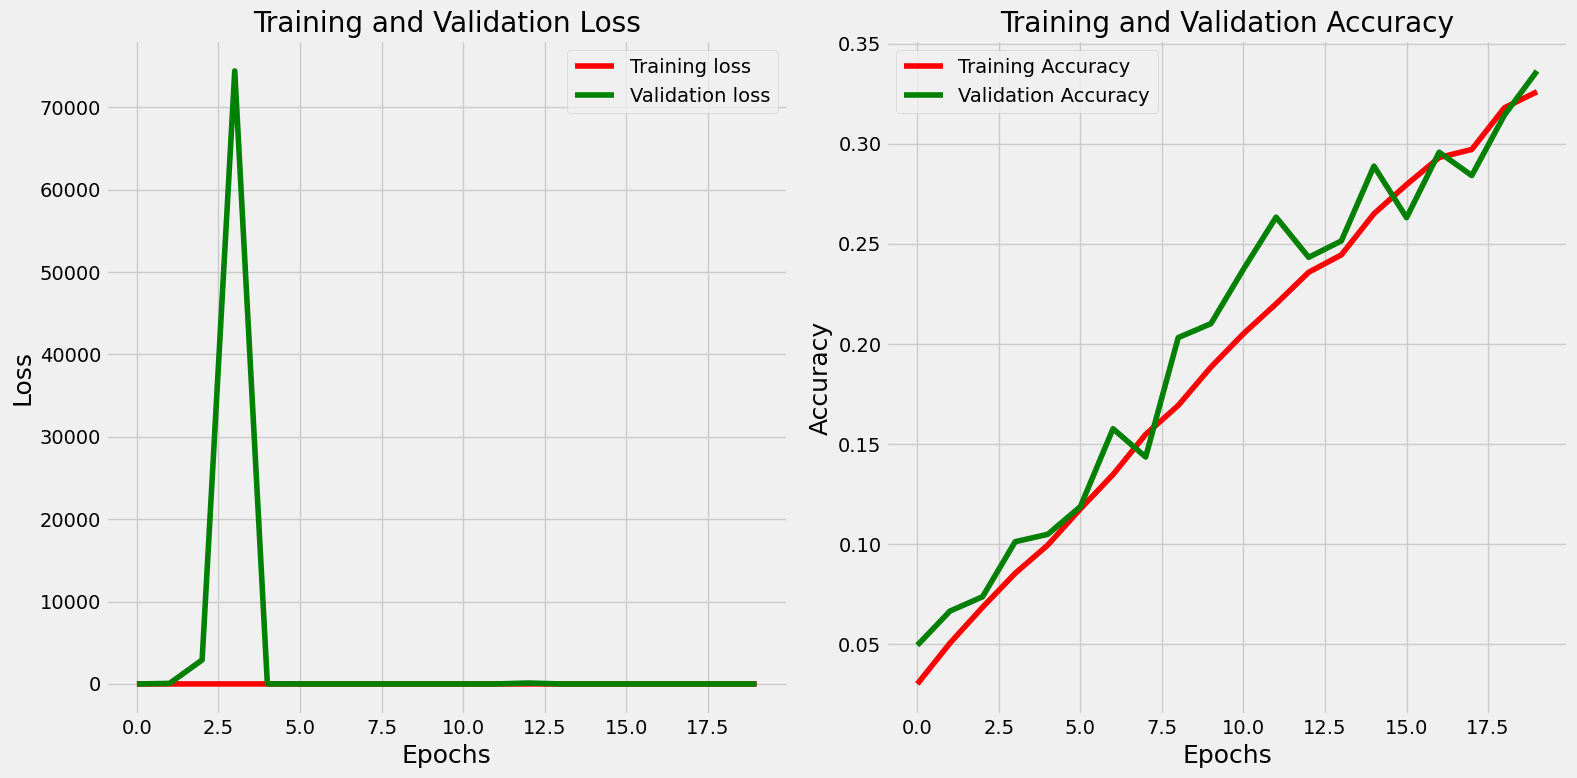

In [16]:
def plot_auc_acc_loss(epochs):
    Epochs = [i for i in range(epochs)]

    plt.style.use('fivethirtyeight')
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))
    
    # Plot Training & Validation Loss
    axes[0].plot(Epochs, train_Loss, 'r', label='Training loss')
    axes[0].plot(Epochs, val_Loss, 'g', label='Validation loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs', fontsize=18)
    axes[0].set_ylabel('Loss', fontsize=18)
    axes[0].legend()

    # Plot Training & Validation Accuracy
    axes[1].plot(Epochs, train_Acc, 'r', label='Training Accuracy')
    axes[1].plot(Epochs, val_Acc, 'g', label='Validation Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs', fontsize=18)
    axes[1].set_ylabel('Accuracy', fontsize=18)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return Epochs

# Menjalankan fungsi plot
Epochs = plot_auc_acc_loss(epochs=20)

/tmp/ipykernel_21361/3185670908.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(net_weight_path, map_location=device))


there were 2681 errors in 4040 tests for an accuracy of 33.64%


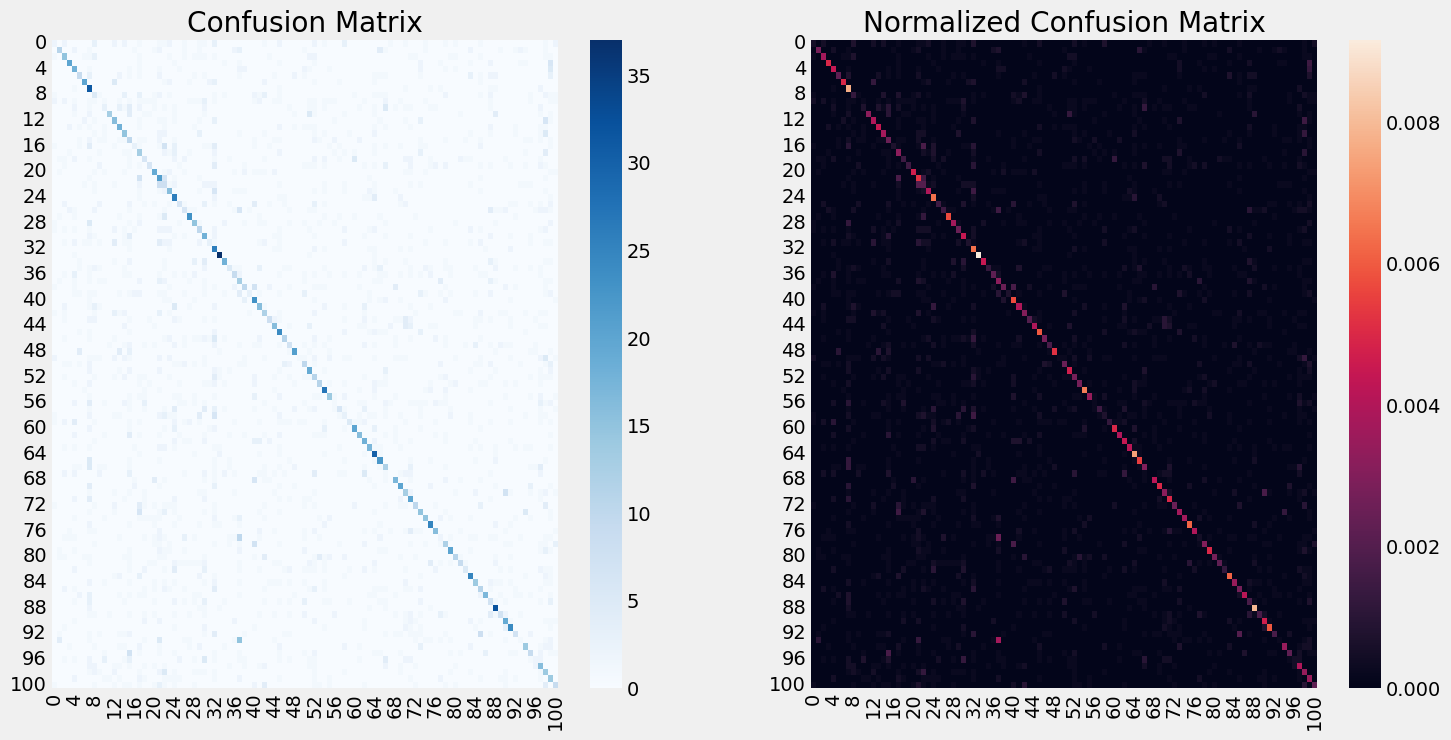

Classification Report:
                          precision    recall  f1-score   support

              apple_pie     0.1176    0.0500    0.0702        40
         baby_back_ribs     0.5000    0.2750    0.3548        40
                baklava     0.3409    0.3750    0.3571        40
         beef_carpaccio     0.6897    0.5000    0.5797        40
           beef_tartare     0.2769    0.4500    0.3429        40
             beet_salad     0.3750    0.2250    0.2812        40
               beignets     0.7407    0.5000    0.5970        40
               bibimbap     0.2385    0.7750    0.3647        40
          bread_pudding     0.1163    0.1250    0.1205        40
      breakfast_burrito     0.0000    0.0000    0.0000        40
             bruschetta     0.1579    0.0750    0.1017        40
           caesar_salad     0.8125    0.3250    0.4643        40
                cannoli     0.3265    0.4000    0.3596        40
          caprese_salad     0.4286    0.4500    0.4390        40


In [15]:
try:
    with open('./classes_indices.json', 'r') as json_file:
        class_indict = json.load(json_file)
except Exception as e:
    print(e)
    exit(-1)

def predictor(testloader):
    errors = 0
    y_pred, y_true = [], []

    # Inisialisasi model dan load weights
    net = DenseNet_121(num_classes=len(class_indict)).to(device)
    net_weight_path = './DenseNet121.pth'
    net.load_state_dict(torch.load(net_weight_path, map_location=device))

    net.eval()
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)

            outputs = net(images)
            preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)

            for i in range(len(preds)):
                y_pred.append(preds[i].cpu().item())
                y_true.append(labels[i].cpu().item())

    tests = len(y_pred)

    for i in range(tests):
        if y_pred[i] != y_true[i]:
            errors += 1

    acc = (1 - errors / tests) * 100
    print(f'there were {errors} errors in {tests} tests for an accuracy of {acc:.2f}%')

    ypred = np.array(y_pred)
    ytrue = np.array(y_true)

    f1score = f1_score(ytrue, ypred, average='weighted') * 100

    class_count = len(list(class_indict.values()))
    classes = list(class_indict.values())

    cm = confusion_matrix(ytrue, ypred)

    # Visualisasi Confusion Matrix
    plt.figure(figsize=(16, 8))
    
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=False, cmap='Blues')
    plt.title("Confusion Matrix")

    plt.subplot(1, 2, 2)
    sns.heatmap(cm / np.sum(cm), annot=False, fmt='.1%')
    plt.title("Normalized Confusion Matrix")

    plt.show()

    # Classification Report
    clr = classification_report(ytrue, ypred, target_names=classes, digits=4)
    print("Classification Report:\n", clr)

    return f1score

# Menjalankan fungsi predictor
f1score = predictor(validloader)